# Lecture: Implementation of Monte Carlo On-Policy Control for Blackjack

## Excercise

### Task 1

Implement an equally distributed stochastic policy for the ``Blackjack-v1`` environment using the dimensions of the ``action_space`` and ``observation_space``.

In [1]:
import gymnasium as gym
import numpy as np

env = gym.make("Blackjack-v1")

dim_A = env.action_space.n
dim_S = [dim.n for dim in env.observation_space]
policy_space = [dim_S[0], dim_S[1], dim_S[2], dim_A]

policy = np.ones(policy_space)/dim_A

# easy testing
assert policy.shape == (32, 11, 2, 2)
assert policy[0,0,0,:].sum() == 1

env.close()

### Task 2
Implement a function ``on_policy_mc_opt(env, $n_{eps}$, policy,
gamma, eps)`` in the ``mc_control_agent.py`` file that implements the General Policy Improvement concept with Monte-Carlo policy evaluation and returns the state evaluation function $Q(s, a)$ and the policy $p$ as return values.

*Note*: Your policy is now a stochastic policy $\pi(a|s)$, i.e. for a given state the policy specifies probabilities for the possible actions. You may have to adjust your choice of action using the policy with respect to your Monte Carlo policy evaluation code from the lecture before.

#### Task 2.1

- Implement the ``gen_eps()`` method in the ``MCControlAgent`` class that generates a single episode given a policy. Mind the Note from above.


In [31]:
import gymnasium as gym
from mc_control_agent_sol import MCControlAgent

env = gym.make("Blackjack-v1")

agent = MCControlAgent(0.9)
episode = agent.gen_eps(env, policy)

print("States: ", [x[0] for x in episode])
print("Actions: ", [x[1] for x in episode])
print("Rewards: ", [x[2] for x in episode])


[((16, 10, 0), 1, 0.0), ((20, 10, 0), 1, -1.0)]
States:  [(16, 10, 0), (20, 10, 0)]
Actions:  [1, 1]
Rewards:  [0.0, -1.0]


#### Task 2.2

- Implement the update step of the Q-value according to the first-visit MC concept in the ``on_policy_mc_opt(env, $n_{eps}$, policy, gamma, eps)`` method

Note that you can get the return going recursively backwards through the episode and use the recursive return equation $G_{t} = R_t + \gamma\cdot G_{t+1}$
- Implement an epsilon greedy policy by adjusting your policy every time you adjust the Q-values and reducing its epsilon for each episode according to

    $$\varepsilon_{k+1} = max (\varepsilon_k \cdot l, 0.01) $$

    where $l$ is the adjustment rate of $\varepsilon$. You can use the default value of $l = 0.99$ here.

In [1]:
import gymnasium as gym
import numpy as np

from mc_control_agent_sol import MCControlAgent

env = gym.make("Blackjack-v1")

# policy als Tabelle mit Wahrscheinlichkeiten für jedes Zustands-Aktionspaar
dim_act_space = env.action_space.n
dim_obs_space = [dim.n for dim in env.observation_space]
policy_space = [dim_obs_space[0], dim_obs_space[1], dim_obs_space[2], dim_act_space]

policy = np.ones(policy_space)/dim_act_space

agent = MCControlAgent(0.9)
Q, p = agent.on_policy_control(env, 500000, policy, eps_decay = 0.9)# Close the env
env.close()

#### Task 2.3

- Plot the policy as well as the state-value function using the two methods ``plot_policy()`` and ``plot_blackjack()``

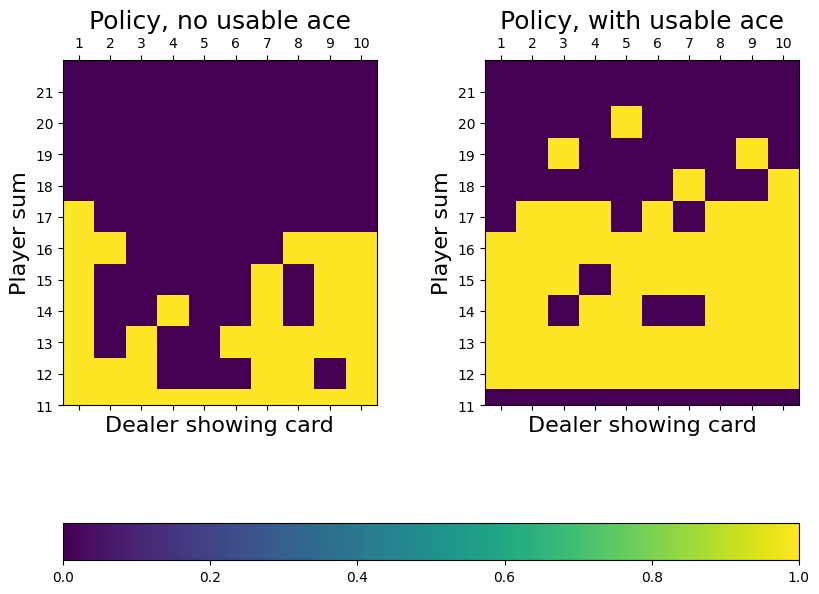

In [2]:
agent.plot_policy(p)

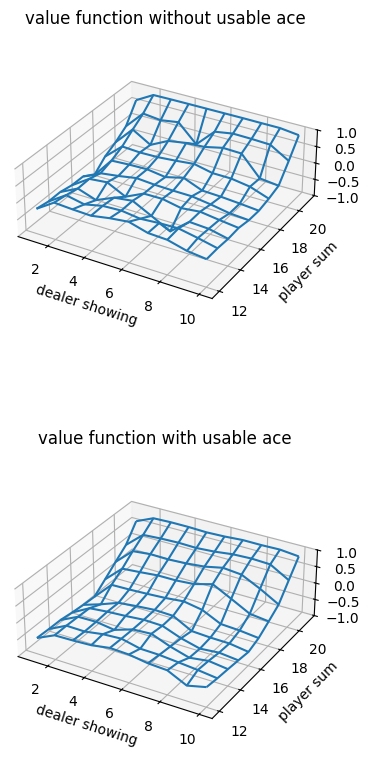

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, figsize=(4, 10),
subplot_kw={'projection': '3d'})
axes[0].set_title('value function without usable ace')
axes[1].set_title('value function with usable ace')
agent.plot_blackjack(env, p, Q, axes[0], axes[1])